# Static maps and numerical methods
This first tutorial selects the fastest available public backend, prints the
actual hardware/runtime, and constructs a static IPM magnification map.  The
CUDA path deliberately uses the production-scale $10^7$ ray budget and a
$1024^2$ source plane. The smaller CPU fallback keeps the notebook executable
on laptops.  The displayed field is a point-source magnification map. No
finite-source convolution or display smoothing is applied.

The first invocation may include PyTorch/Triton compilation or an on-disk
compiler-cache lookup.  The repeated values are synchronized steady-state
times.  As in the paper figures, the map uses a physical scale bar rather
than redundant coordinate ticks and shows $\log_{10}\mu$ with a panel-height
colorbar.

The benchmark calls the same map calculation repeatedly and therefore shows first-call versus warmed execution directly. Compatible systems created later in the same Python process reuse the same compiled kernels. For many independent stellar realizations of one macroimage, `mc.batched_system_maps(...)` can fuse compatible maps while keeping every star field scientifically independent. The getting-started and training-set notebooks explain which physical parameters may vary without changing the compiled numerical shapes.


In [1]:
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available
runtime_config = mc.RuntimeConfig(
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda and capabilities.triton_importable else "auto",
    dtype=torch.float32,
    strict_backend=use_cuda and capabilities.triton_importable,
)
print(mcp.runtime_description())


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0


In [2]:
stars = mc.PointMassField(
        x_uas=torch.tensor([-1.1, 0.3, 1.4]),
        y_uas=torch.tensor([0.7, -0.4, 0.1]),
        mass_solar=torch.tensor([0.002739, 0.001636, 0.002264]),
)
lens_region = mc.PlaneRegion((6.0, 6.0))
source_resolution = 1024 if use_cuda else 256
ray_count = 10_000_000 if use_cuda else 262_144
system = mc.MicrolensingSystem(
    macro=mc.MacroLens(convergence=0.35, shear=0.15),
    distances=mc.LensingDistances(8.0e24, 1.6e25, 9.0e24),
    stars=stars, lens_region=lens_region,
    runtime=runtime_config,
)
method = mc.production_ipm_config(
    scout_ratio=1,
        rays=ray_count,
    cell_chunk_size=524_288 if use_cuda else 65_536,
)

def make_map():
    return system.magnification_map(
        map_width_uas=4.0, map_pixels=source_resolution, method=method
    )

print(f"Map configuration: N={ray_count:,}, source={source_resolution} x {source_resolution}")


Map configuration: N=10,000,000, source=1024 x 1024


src\microcaustics\solvers\ipm.py:900: CompilationWarning: Compilation event 1: preparing a new Triton specialization for IPM rasterization on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  _warn_new_triton_ipm_specialization(


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0
static IPM map first call in this process: 2.73436 s
static IPM map warmed steady state: 0.0735501 s (median of 3, sample std=0.005 s)
First-call excess includes compilation when needed, plus allocator and cache initialization. An on-disk compiler cache may already be warm.


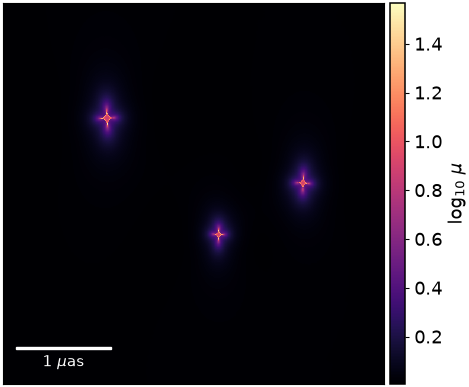

In [3]:
benchmark = mc.benchmark_callable(
    make_map,
    warmup=1,
    repeats=3,
    synchronize=(torch.cuda.synchronize if use_cuda else None),
)
mcp.print_benchmark(benchmark, label="static IPM map")
magnification_map = benchmark.first_result
figure, ax = mcp.plot_magnification_map(
    magnification_map,
    log10=True,
    scale_bar_uas=1.0,
    show_axes=False,
)
figure.tight_layout()


## Eager, compiled, and Triton backends

Backend choice is independent of the numerical IPM controls. The compact
comparison below deliberately uses a smaller map so it can expose first-call
and warmed behavior without repeating the production-scale calculation above.
All available backends receive the same lens, grid, and static-map preset. The
reported maximum difference checks that changing implementation did not change
the requested calculation. `torch-compile-partial` is an honest description of
the portable IPM path. Ray queries are compiled, while exact polygon clipping
remains portable PyTorch. CUDA float32 Triton fuses the complete raster path.


In [4]:
backend_names = ["torch-eager"]
if capabilities.torch_compile_available:
    backend_names.append("torch-compile")
if use_cuda and capabilities.triton_importable:
    backend_names.append("triton")

demo_method = mc.production_ipm_config(
    scout_ratio=1,
    rays=16_384, cell_chunk_size=4_096,
)
backend_results = {}
for backend_name in backend_names:
    backend_runtime = mc.RuntimeConfig(
        device="cuda" if use_cuda else "cpu",
        backend=backend_name, dtype=torch.float32, strict_backend=False,
    )
    backend_system = mc.MicrolensingSystem(
        macro=system.macro, distances=system.distances, stars=stars,
        lens_region=lens_region, runtime=backend_runtime,
    )
    measured = mc.benchmark_callable(
        lambda: backend_system.magnification_map(
            map_width_uas=4.0, map_pixels=64, method=demo_method
        ),
        warmup=1, repeats=3,
        synchronize=(torch.cuda.synchronize if use_cuda else None),
    )
    backend_results[backend_name] = measured.first_result
    mcp.print_benchmark(measured, label=backend_name)
    print("  effective backend:", measured.first_result.metadata.get("effective_backend"))

eager_values = backend_results["torch-eager"].values
for backend_name, product in backend_results.items():
    maximum_difference = float((product.values - eager_values).abs().max().cpu())
    print(f"{backend_name:>13s}: max |map - eager| = {maximum_difference:.3e}")


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0
torch-eager first call in this process: 4.16523 s
torch-eager warmed steady state: 5.22713 s (median of 3, sample std=0.221 s)
First-call excess includes compilation when needed, plus allocator and cache initialization. An on-disk compiler cache may already be warm.
  effective backend: torch-eager


src\microcaustics\solvers\far_field.py:482: CompilationWarning: Compilation event 2: preparing a new torch.compile specialization for far-field approximation deflection query on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  (alpha_x, alpha_y), compiled = run_tensor_kernel(


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0
torch-compile first call in this process: 6.79738 s
torch-compile warmed steady state: 4.89972 s (median of 3, sample std=0.224 s)
First-call excess includes compilation when needed, plus allocator and cache initialization. An on-disk compiler cache may already be warm.
  effective backend: torch-compile-partial


src\microcaustics\solvers\ipm.py:900: CompilationWarning: Compilation event 3: preparing a new Triton specialization for IPM rasterization on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  _warn_new_triton_ipm_specialization(


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0
triton first call in this process: 1.91447 s
triton warmed steady state: 0.0137398 s (median of 3, sample std=0.00017 s)
First-call excess includes compilation when needed, plus allocator and cache initialization. An on-disk compiler cache may already be warm.
  effective backend: triton
  torch-eager: max |map - eager| = 0.000e+00
torch-compile: max |map - eager| = 1.907e-06
       triton: max |map - eager| = 3.157e-04


## Static-map solvers and numerical methods

The following section continues the workflow with the complementary use case.


## Static IRS and IPM on one registered source grid

This notebook compares inverse ray shooting (IRS) and inverse polygon mapping
(IPM) without changing the lens realization, source-plane aperture, or pixel
grid. The CUDA run uses the production $10^7$-ray IPM map and a substantially
larger $2\times10^8$ Cartesian IRS sample on the same $1024^2$ source plane.
The unequal budgets are intentional. They show why polygon-area deposition
reaches a smooth point-source map with far fewer image-plane samples than IRS.

`IRSConfig` supports two sampling rules. `sampling="cartesian"` is the
deterministic package default and places rays at regular cell centers.
`sampling="random"` gives the conventional Monte Carlo control. Its seed
selects a reproducible ray set, and that same set is reused at every dynamic
epoch so shot noise does not create artificial temporal variability. Both
options support the exact and local-exact far-field ray tracers and the full or
rectangular integration domains.

The final panel is $-2.5\log_{10}(\mu_{\rm IRS}/\mu_{\rm IPM})$ in
magnitudes.

In [5]:
from pathlib import Path
import numpy as np
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available
runtime_config = mc.RuntimeConfig(
    profiling="detailed",  # opt in to synchronized component timings
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda and capabilities.triton_importable else "auto",
    dtype=torch.float32,
    strict_backend=use_cuda and capabilities.triton_importable,
)
print(mcp.runtime_description())


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0


In [6]:
stars = mc.PointMassField(
        x_uas=torch.tensor([-0.8, 0.2, 0.9]),
        y_uas=torch.tensor([0.4, -0.5, 0.1]),
        mass_solar=torch.tensor([0.003260, 0.002043, 0.002496]),
)
region = mc.PlaneRegion((5.0, 5.0))
resolution = 1024 if use_cuda else 256
grid = mc.PlaneGrid((resolution, resolution), (2.0, 2.0))
system = mc.MicrolensingSystem(
    macro=mc.MacroLens(convergence=0.2, shear=0.08),
    distances=mc.LensingDistances(8.0e24, 1.6e25, 9.0e24),
    stars=stars, source_grid=grid, lens_region=region, runtime=runtime_config,
)
simulation = system.realize().simulation  # advanced method diagnostics below
ipm_rays = 10_000_000 if use_cuda else 262_144
irs_rays = 200_000_000 if use_cuda else 4_194_304
print(
    f"IPM N={ipm_rays:,}; IRS N={irs_rays:,}; "
    f"source={resolution} x {resolution}"
)


IPM N=10,000,000; IRS N=200,000,000; source=1024 x 1024


In [7]:
ipm = simulation.magnification_map(
    region,
    grid,
    method=mc.IPMConfig(
        rays=ipm_rays,
        scout_ratio=2,
        refinement=2,
        virtual_refinement=4,
        tiled=False,
        far_field_approx=mc.FarFieldApproxConfig(enabled=False),
    ),
)
tiled_ipm = simulation.magnification_map(
    region,
    grid,
    method=mc.production_ipm_config(
        rays=ipm_rays,
        far_field_approx=mc.FarFieldApproxConfig(enabled=False),
    ),
)
irs = simulation.magnification_map(
    region,
    grid,
    method=mc.IRSConfig(
        rays=irs_rays,
        sampling="cartesian",
        far_field_approx=mc.FarFieldApproxConfig(enabled=False),
    ),
)
comparison = mc.compare_magnification_maps(irs.values, ipm.values)
print("Full-field IPM steady time [s]:", ipm.timing.delivered_seconds)
print("Source-scouted tiled IPM steady time [s]:", tiled_ipm.timing.delivered_seconds)
print("IRS steady time [s]:", irs.timing.delivered_seconds)
print(comparison)


src\microcaustics\solvers\direct.py:198: CompilationWarning: Compilation event 4: preparing a new torch.compile specialization for direct deflection block on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  (chunk_alpha_x, chunk_alpha_y), used = run_tensor_kernel(


src\microcaustics\solvers\ipm.py:900: CompilationWarning: Compilation event 5: preparing a new Triton specialization for IPM rasterization on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  _warn_new_triton_ipm_specialization(


src\microcaustics\solvers\irs.py:192: CompilationWarning: Compilation event 6: preparing a new torch.compile specialization for IRS deposition on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  deposited, used = run_tensor_kernel(


Full-field IPM steady time [s]: 2.2250119000091217
Source-scouted tiled IPM steady time [s]: 1.3195983000041451
IRS steady time [s]: 1.121688199986238
MapComparison(linear_nrmse=0.04439018345286578, fractional_nrmse=0.060065456149908776, rmse_mmag=65.38174571193622, bias_mmag=1.9678385310732294, p95_absolute_mmag=148.77840944001517, valid_pixels=1048576)


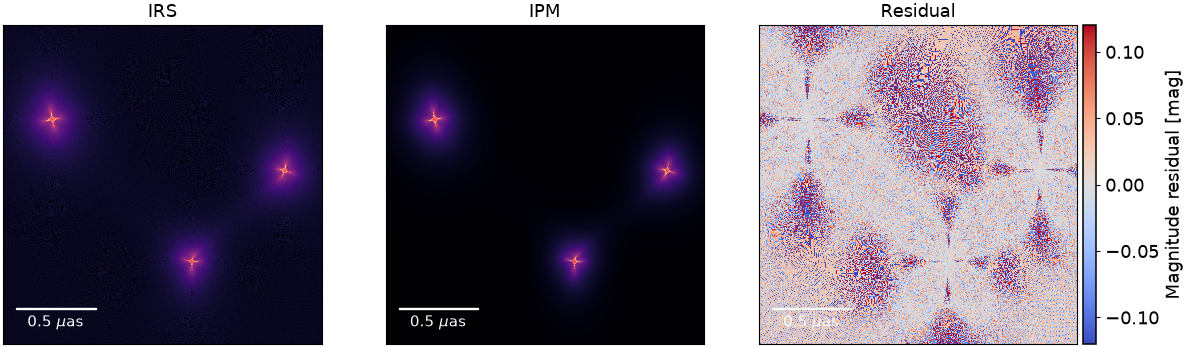

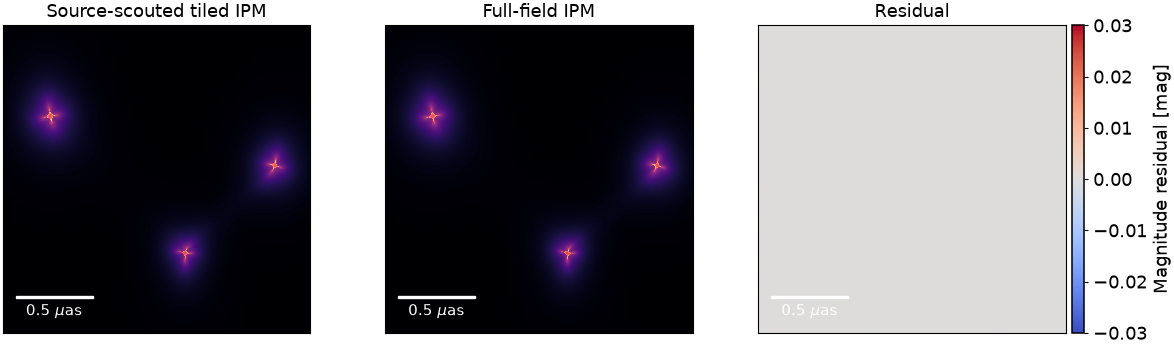

In [8]:
figure, axes = mcp.plot_map_comparison(
    irs,
    ipm,
    residual="magnitude",
    residual_limit=0.12,
    scale_bar_uas=0.5,
    show_axes=False,
)
axes[0].set_title("IRS")
axes[1].set_title("IPM")
axes[2].set_title("Residual")
figure.set_size_inches(12.8, 3.8)
figure.tight_layout()

figure, axes = mcp.plot_map_comparison(
    tiled_ipm, ipm, residual="magnitude", residual_limit=0.03,
    scale_bar_uas=0.5, show_axes=False,
)
axes[0].set_title("Source-scouted tiled IPM")
axes[1].set_title("Full-field IPM")
axes[2].set_title("Residual")
figure.set_size_inches(12.8, 3.8)
figure.tight_layout()


### Cartesian and random IRS

The two IRS modes below use the same requested ray count and physical geometry.
The Cartesian result is deterministic. The random result records both its user
seed and the derived coordinate-stream seeds in the map metadata. Change the
seed to draw another Monte Carlo realization. Changing only `ray_chunk_size`
does not change either ray set.

Cartesian metadata: {'sampling': 'cartesian', 'seed': None, 'coordinate_seeds': None, 'requested_rays': 10000000, 'actual_rays': 10001406, 'ray_grid_shape': [3163, 3162], 'lens_region': {'field_of_view_uas': [5.0, 5.0], 'center_uas': [0.0, 0.0]}, 'absolute_magnification': True, 'requested_backend': 'triton', 'effective_backend': 'torch-compile', 'backend_components': {'raytrace': 'torch-compile', 'deposition': 'torch-compile'}, 'far_field': {'enabled': False}, 'dtype': 'torch.float32'}
Random metadata: {'sampling': 'random', 'seed': 0, 'coordinate_seeds': {'x': 2753223069752212405, 'y': 1262348390277018814}, 'requested_rays': 10000000, 'actual_rays': 10000000, 'ray_grid_shape': None, 'lens_region': {'field_of_view_uas': [5.0, 5.0], 'center_uas': [0.0, 0.0]}, 'absolute_magnification': True, 'requested_backend': 'triton', 'effective_backend': 'torch-compile', 'backend_components': {'raytrace': 'torch-compile', 'deposition': 'torch-compile'}, 'far_field': {'enabled': False}, 'dtype': 'tor

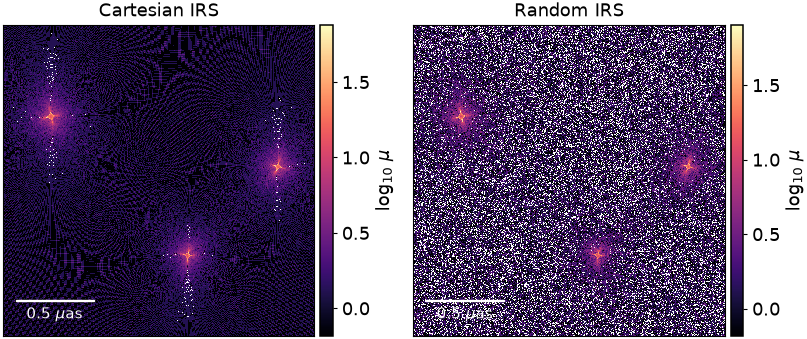

In [9]:
irs_sampling_rays = 10_000_000 if use_cuda else 262_144
cartesian_irs = simulation.magnification_map(
    region, grid,
    method=mc.IRSConfig(
        rays=irs_sampling_rays,
        sampling="cartesian",
        far_field_approx=mc.FarFieldApproxConfig(enabled=False),
    ),
)
random_irs = simulation.magnification_map(
    region, grid,
    method=mc.IRSConfig(
        rays=irs_sampling_rays,
        sampling="random",
        seed=0,
        far_field_approx=mc.FarFieldApproxConfig(enabled=False),
    ),
)

figure, axes = plt.subplots(1, 2, figsize=(8.4, 3.8))
for axis, result, title in zip(
    axes, (cartesian_irs, random_irs), ("Cartesian IRS", "Random IRS")
):
    mcp.plot_magnification_map(
        result, ax=axis, log10=True, scale_bar_uas=0.5, show_axes=False
    )
    axis.set_title(title)
figure.tight_layout()
print("Cartesian metadata:", cartesian_irs.metadata)
print("Random metadata:", random_irs.metadata)

## How tiled IPM selects and maps cells

This cell generates the manuscript-style Figure 3 geometry from a seeded
Q2237 image-B realization. The retained scout cells use $k=2$. The selected
fine cell is evaluated at the true $r+1$ by $r+1$ nodes, reconstructed on
the virtual $v=4$ lattice, split into mapped triangles, and clipped against
the native source-pixel grid. No saved diagnostics or rendered image are
loaded.

The scout controls are deliberately separate. `scout_ratio` ($k$) sets the
coarse discovery-grid spacing. `scout_halo_pixels` expands the source
aperture before the mapped-cell test, whereas `scout_dilation_cells` adds a
support ring to the selected mask in the lens plane. `scout_trace_centers`
adds mapped cell-center queries. The validated fast dynamic preset uses $k=2$,
zero source-pixel halo, one cell of lens-plane dilation, and corner-only
scouting. A standalone static map defaults to the complete $k=1$ scout
with center probes.

## Apertures, light loss, and the controls that change accuracy

`light_loss` is an aperture-sizing tolerance used by the rectangular lens-region estimate. It is not a request to discard that fraction of the final map or light curve. A finite rectangular image-plane aperture can nevertheless omit rays and caustics outside its boundary. The production tiled calculation therefore uses the complete circular stellar field and selects only cells that map into the requested source aperture. In the training examples, the circular lens diameter is conservatively set to 1.5 times the diagonal of the 1%-light-loss rectangular estimate. This multiplicative safety scale increases the physical stellar aperture. Increasing it adds stars and cost, while convergence should leave the central source map unchanged.

The main numerical controls are deliberately independent:

| Control | Meaning | Primary effect |
|---|---|---|
| source field of view and pixel shape | Physical map aperture and requested output sampling | Scientific coverage, memory, and required ray density |
| lens region, `light_loss`, and safety scale | Physical point-mass aperture | Boundary bias, star count, and cost |
| stellar mass function, compact fraction, positions, velocities | Physical microlens realization | Caustic density and temporal evolution |
| `rays` ($N$) | Requested base image-plane cell budget | Map sampling and runtime |
| `scout_ratio` ($k$) | Coarsening used only to discover source-mapping cells | Scout cost and completeness |
| `refinement` ($r$) | True lens-equation subdivision inside retained cells | Accuracy and lens evaluations |
| `virtual_refinement` ($v$) | Interpolated polygon subdivision after tracing | Rasterization accuracy without new lens evaluations |
| `tiled` | Use the source scout rather than all image-plane cells | Usually the largest spatial saving |
| `scout_halo_pixels`, `scout_dilation_cells` | Enlarge retained source/lens support | Completeness versus extra cells |
| `dual_scout_scalar_correction` | One frame-zero $k=1$ normalization for dynamic $k=2$ runs | Removes the small tiled flux offset |
| far-field cell/node counts, exact radius, Taylor order | Split nearby exact stars from distant analytic expansions | Ray-trace speed and approximation error |
| detA grid resolution, anchors, gauges | Resolve critical curves and robustly label the source center | Caustic/label accuracy and memory |
| map cadence and source cadence | Separate slow lens evolution from fast intrinsic source evolution | Temporal accuracy and runtime |
| temporal batch, spatial chunk, scout refresh | Scheduling controls with fixed mathematics | Throughput and peak memory |
| backend and dtype | Triton/compiled/eager execution and numerical precision | Portability, speed, and roundoff floor |

The validated dynamic preset is $N=10^7$, $k=2$, $r=2$, $v=4$, zero source-pixel halo, one retained-cell dilation, and the frame-zero $k=1\rightarrow2$ correction. Independent static maps default to $k=1$ and need no correction. The far field uses a $16\times16$ lens partition, $8\times8$ Taylor nodes per partition cell, a one-cell exact-neighbor radius, degree four evaluation, and degree ten center translation. Dynamic runs refresh the endpoint-union scout every ten frames. Batch and chunk values should be tuned to the available accelerator. They must not be used to alter scientific convergence. Always reconverge $N$, $r$, $v$, aperture size, and detA resolution when the macro model or source angular scale changes substantially.

In [10]:
dynamic_scout = mc.production_ipm_config()
static_scout = mc.production_ipm_config(
    scout_ratio=1, scout_trace_centers=True,
)
conservative_scout = mc.production_ipm_config(
    scout_halo_pixels=1.0,      # expand the source aperture by one pixel
    scout_dilation_cells=2,     # retain two neighboring lens-plane rings
    scout_trace_centers=True,   # optional center-assisted validation
)
complete_scout = mc.production_ipm_config(
    scout_ratio=1,
    dual_scout_scalar_correction=False,
    scout_trace_centers=True,
)

for name, config in {
    "dynamic production": dynamic_scout,
    "independent static": static_scout,
    "larger safety margins": conservative_scout,
    "complete tiled scout": complete_scout,
}.items():
    print(
        f"{name:24s} k={config.scout_ratio}, "
        f"source halo={config.scout_halo_pixels:g} px, "
        f"lens dilation={config.scout_dilation_cells}, "
        f"center probes={config.scout_trace_centers}"
    )


dynamic production       k=2, source halo=0 px, lens dilation=1, center probes=False
independent static       k=1, source halo=0 px, lens dilation=1, center probes=True
larger safety margins    k=2, source halo=1 px, lens dilation=2, center probes=True
complete tiled scout     k=1, source halo=0 px, lens dilation=1, center probes=True


Derived source field [microarcsec]: (9.381915699013257, 9.381915699013257)
Derived lens field [microarcsec]: (756.5716859143279, 756.5716859143279)


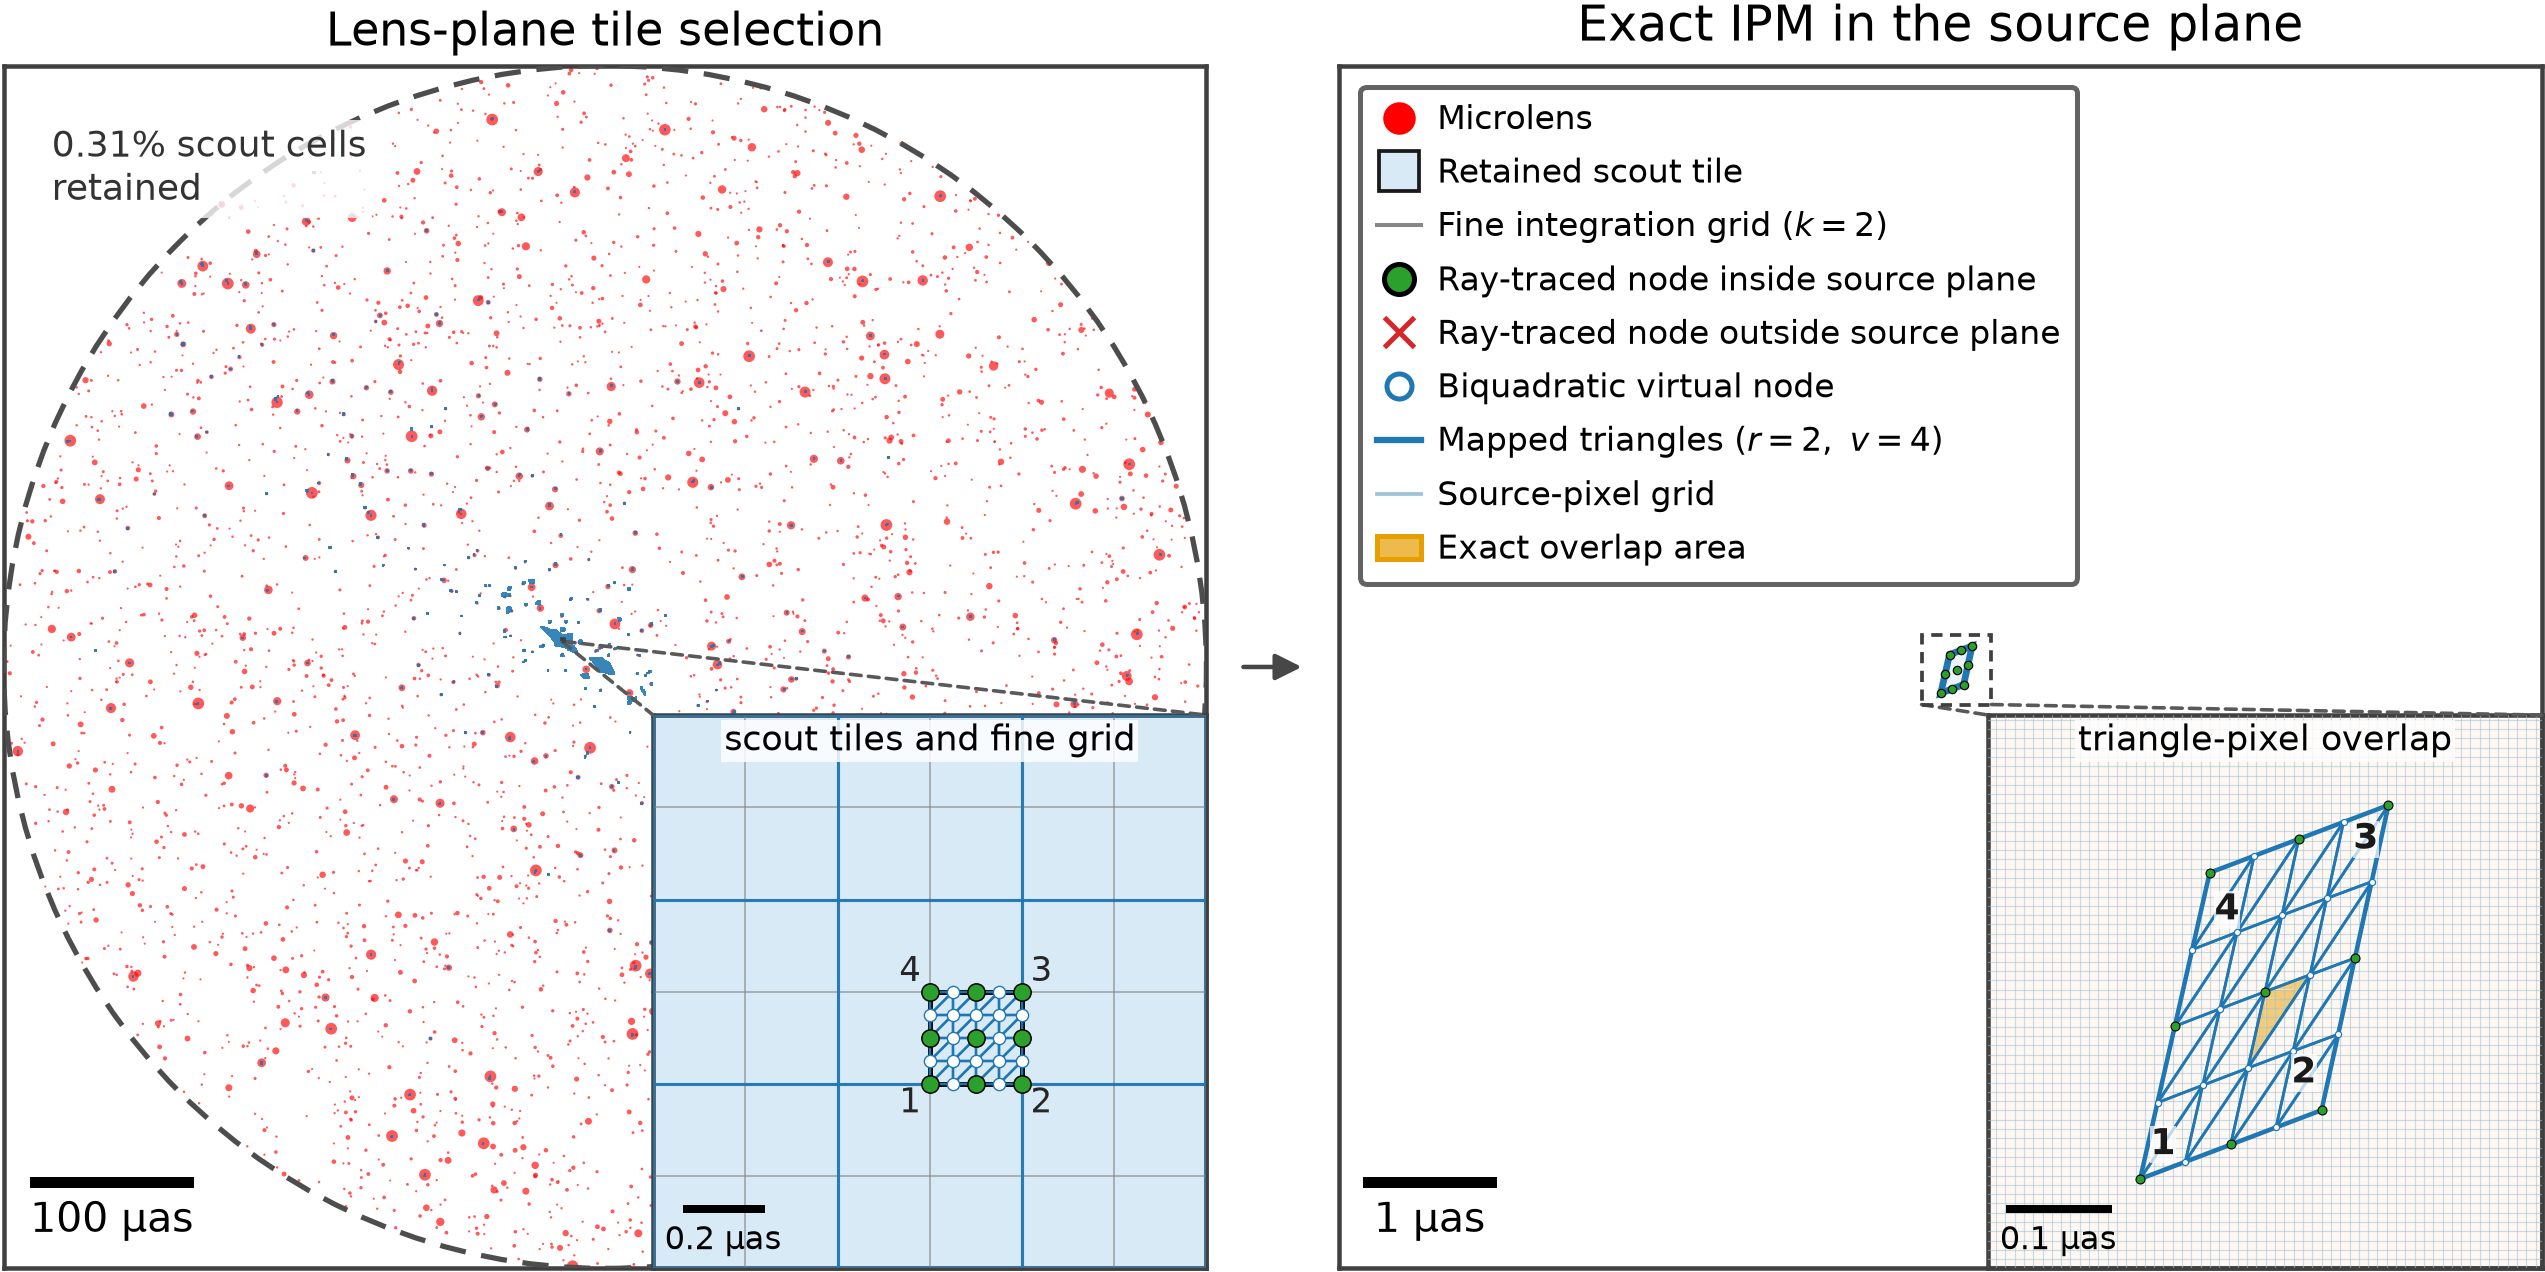

In [11]:
q_lens_redshift, q_source_redshift = 0.0395, 1.695
# Supply the observed shear position angle. Source scouting and the full
# field stay in this sky frame; only the separate rectangle comparison
# below uses an internally shear-aligned numerical frame.
q_macro = mc.MacroLens(
    convergence=0.391, shear=0.391, shear_angle_deg=141.73,
    smooth_matter_fraction=0.0,
)
q_population = mc.StellarPopulation.salpeter(
    mean_mass_solar=0.3,
    mass_ratio=100.0,
    kinematics=mc.SkyProjectedKinematics(
        ra_deg=340.126125, dec_deg=3.358611,
        stellar_dispersion_km_s=170.0,
        peculiar_velocity_dispersion_km_s=235.0,
        include_cmb_dipole=True, seed=0,
    ),
)
q_resolution = 1024 if use_cuda else 256
q_source = mc.ThinDiskModel(
    black_hole_mass_solar=10.0**9.08,
    eddington_ratio=0.34,
    bands_angstrom={"u": 3671.0, "g": 4827.0, "r": 6223.0,
           "i": 7546.0, "z": 8691.0, "y": 9712.0},
    source_redshift=q_source_redshift,
    spin=0.74,
    inclination_deg=10.0,
    position_angle_deg=0.0,
    support_lamp_fraction=0.1,
    support_corona_height_above_isco_rg=20.0,
    source_grid_shape=q_resolution,
    enclosed_flux_fraction=0.999,
    source_margin=1.05,
)
q_system = mc.MicrolensingSystem(
    lens_redshift=q_lens_redshift,
    source_redshift=q_source_redshift,
    H0=70.0,
    Om0=0.3,
    macro=q_macro,
    source=q_source,
    stellar_population=q_population,
    duration_days=3650.0,
    light_loss=0.01,
    safety_scale=1.5,
    seed=0,
    runtime=runtime_config,
)
q_realization = q_system.realize()
q_simulation = q_realization.simulation
q_lens_region = q_realization.stellar_aperture.bounding_region
q_grid = q_realization.source_grid
q_rays = 10_000_000 if use_cuda else 262_144
# Use the dynamic production scout here because this schematic explains
# the validated k=2 path. Independent static maps default to k=1.
q_tiled_method = mc.production_ipm_config(rays=q_rays)
from IPython.display import Image, display

# Generate the scout mask and mapped IPM cell from this live Q2237 B
# realization. No archived diagnostic arrays are loaded.
paper_ipm_paths = mcp.render_live_paper_ipm_schematic(
    q_simulation,
    q_lens_region,
    q_grid,
    q_tiled_method,
    Path("static_map_tutorial_output"),
    time_days=0.0,
    output_prefix="q2237_image_b_scout_and_ipm",
)
print("Derived source field [microarcsec]:", q_grid.field_of_view_uas)
print("Derived lens field [microarcsec]:", q_lens_region.field_of_view_uas)
display(Image(filename=str(paper_ipm_paths[0])))


## Full and rectangular lens-plane apertures

A rectangular aperture can reduce work when it follows the macro-stretched
preimage of the requested source field. The high-level system changes to the
shear eigenframe internally and applies the same basis change to the stars,
velocities, source position angle, and trajectory. The physical disk is not
rotated or resampled as an image. It is not equivalent to the package's
full-star-field tile scout. A rectangle discards cells outside its boundary,
so an insufficient aperture can lose a nearly constant amount of flux or miss
a caustic that enters from outside. The calculation below holds the lens-plane
cell density fixed and changes only the aperture height. Its residual is shown
without subtracting a fitted offset. For an unrelated static map the tiled
alternative should normally start at `k=1`. The dynamic-only `k=1` to `k=2`
normalization repair is intentionally not used here.


Full aperture: 10,000,000 cells; rectangular aperture: 7,000,000 cells at the same nominal density
Raw full-versus-rectangle comparison: MapComparison(linear_nrmse=0.0007706564735861646, fractional_nrmse=7.957706954471908e-05, rmse_mmag=0.08640289826830903, bias_mmag=3.794896256795218e-05, p95_absolute_mmag=0.14883409611951992, valid_pixels=1048576)


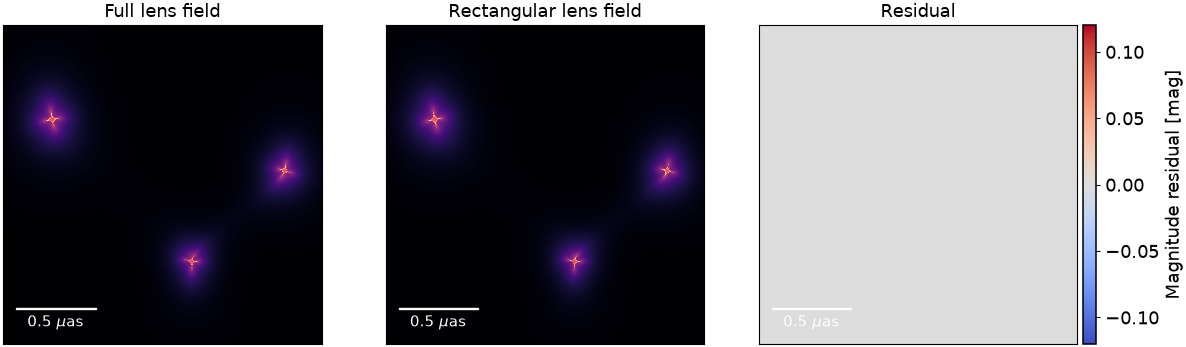

In [12]:
rectangular_region = mc.PlaneRegion((3.5, 5.0))
rectangular_rays = int(round(ipm_rays * 3.5 / 5.0))
rectangular_ipm = simulation.magnification_map(
    rectangular_region,
    grid,
    method=mc.IPMConfig(
        rays=rectangular_rays, refinement=2, virtual_refinement=4,
        tiled=False, far_field_approx=mc.FarFieldApproxConfig(enabled=False),
    ),
)
rectangular_comparison = mc.compare_magnification_maps(
    ipm.values, rectangular_ipm.values,
)
print(
    f"Full aperture: {ipm_rays:,} cells; rectangular aperture: "
    f"{rectangular_rays:,} cells at the same nominal density"
)
print("Raw full-versus-rectangle comparison:", rectangular_comparison)
figure, axes = mcp.plot_map_comparison(
    ipm, rectangular_ipm, residual="magnitude",
    residual_limit=0.12, scale_bar_uas=0.5, show_axes=False,
)
axes[0].set_title("Full lens field")
axes[1].set_title("Rectangular lens field")
axes[2].set_title("Residual")
figure.set_size_inches(12.8, 3.8)
figure.tight_layout()


## Realistic Q2237 B lens-plane strategies

The compact example above isolates the numerical methods. This comparison
reuses the same live sky-frame Q2237 image-B realization as the scout schematic, so the
cosmology, macro shear direction, Salpeter catalog, random seed, and source
grid are identical. The rectangle is shown at its physical shear angle even
though its numerical integration uses shear-aligned local coordinates. The
first row shows which part of the common lens plane
each strategy integrates. The second row compares their point-source maps on
one registered grid. For visual map quality, each map receives the same total
base-cell budget. This is not a fixed-density timing comparison.


Q2237 B stars: 3830
Full lens FOV [uas]: (756.5716859143279, 756.5716859143279)
Rectangular preimage FOV [uas]: (106.41556322190785, 488.1447854215957)


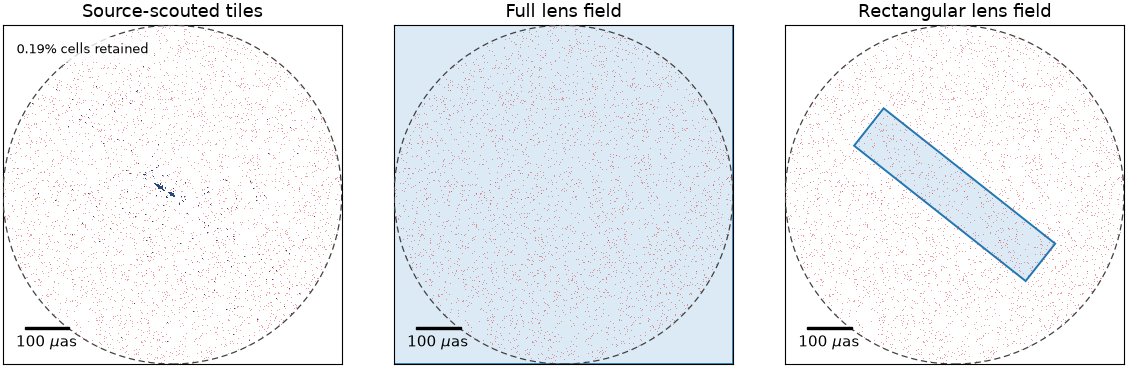

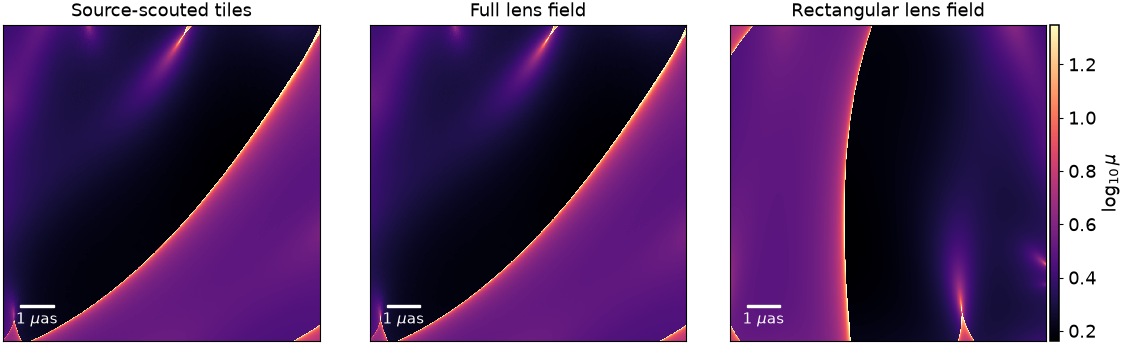

Visual fixed-N map times [s] (not a fixed-density timing comparison): {'tiled': 0.9165484999830369, 'full': 1.2082663999754004, 'rectangle': 2.554477500001667}


In [13]:
# Reuse the Q2237 B system constructed once above.
q_mass_function = q_population.mass_function
q_tiled_method = mc.production_ipm_config(rays=q_rays, scout_ratio=1)
q_full_method = mc.IPMConfig(
    rays=q_rays, scout_ratio=1, refinement=2, virtual_refinement=4,
    tiled=False, cell_chunk_size=q_tiled_method.cell_chunk_size,
    far_field_approx=q_tiled_method.far_field_approx,
)
# The source-scouted and full-field panels remain in the input sky frame.
# The conventional narrow rectangle is derived from the same physical
# system in its internally shear-aligned numerical frame.
q_rectangle_realization = q_system.with_integration_domain("rectangle").realize()
q_rectangle = q_rectangle_realization.lens_region
print('Q2237 B stars:', len(q_realization.stars))
print('Full lens FOV [uas]:', q_lens_region.field_of_view_uas)
print('Rectangular preimage FOV [uas]:', q_rectangle.field_of_view_uas)
lens_figure, lens_axes = mcp.plot_lens_field_strategies(
    q_simulation, q_lens_region, q_grid, q_tiled_method, q_rectangle,
    rectangle_rotation_deg=q_rectangle_realization.sky_to_local_rotation_deg,
    scale_bar_uas=100.0,
)
lens_figure.tight_layout()
display(lens_figure)
plt.close(lens_figure)

q_tiled_map = q_simulation.magnification_map(
    q_lens_region, q_grid, method=q_tiled_method,
)
q_full_map = q_simulation.magnification_map(
    q_lens_region, q_grid, method=q_full_method,
)
q_rectangle_map = q_rectangle_realization.magnification_map(
    method=q_full_method,
)
q_logs = [
    np.log10(np.clip(product.values.detach().cpu().numpy(), 1.0e-12, None))
    for product in (q_tiled_map, q_full_map, q_rectangle_map)
]
q_finite = np.concatenate([values[np.isfinite(values)] for values in q_logs])
q_vmin, q_vmax = np.quantile(q_finite, (0.002, 0.998))
map_figure, map_axes = plt.subplots(1, 3, figsize=(11.8, 3.7))
for axis, product, title in zip(
    map_axes, (q_tiled_map, q_full_map, q_rectangle_map),
    ('Source-scouted tiles', 'Full lens field', 'Rectangular lens field'),
    strict=True,
):
    mcp.plot_magnification_map(
        product, ax=axis, colorbar=False, title=title, show_axes=False,
        scale_bar_uas=1.0, vmin=q_vmin, vmax=q_vmax,
    )
mcp.panel_colorbar(
    map_figure, map_axes[-1], map_axes[-1].images[0],
    label=r'$\log_{10}\mu$', size='3%', pad=0.035,
)
map_figure.tight_layout()
display(map_figure)
plt.close(map_figure)
print('Visual fixed-N map times [s] (not a fixed-density timing comparison):', {
    'tiled': q_tiled_map.timing.delivered_seconds,
    'full': q_full_map.timing.delivered_seconds,
    'rectangle': q_rectangle_map.timing.delivered_seconds,
})


### Automatic and explicit lens-plane geometry

The default `lens_plane_uas="auto"` encloses the macro preimage, every supplied point lens, and an Einstein-radius guard. You normally omit it. A scalar requests a centered square and a two-value tuple requests `(height, width)` in microarcseconds. Use `PlaneRegion` only for an off-center advanced calculation.

Coordinates can also be specified in units of the Einstein radius of a chosen mean microlens. The conversion helpers use the same redshifts and cosmology as the system.


`python
theta_mean_uas = mc.einstein_radius_uas(
    0.3, lens_redshift=0.5, source_redshift=2.0, device="cpu"
)
coordinates_uas = mc.einstein_units_to_uas(
    [-2.0, 0.0, 2.0], mean_mass_solar=0.3,
    lens_redshift=0.5, source_redshift=2.0, device="cpu",
)
explicit_square = mc.MicrolensingSystem(
    macro=system.macro, distances=system.distances,
    stars=system.stars, lens_plane_uas=12.0,
)
print("Mean Einstein radius [microarcsec]:", float(theta_mean_uas))
print("Coordinates [microarcsec]:", coordinates_uas.tolist())
`
